In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score

sns.set_style('whitegrid')


C:\Users\abbas\AppData\Local\Temp\ipykernel_8336\258523554.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})


Shape: (7043, 20)
Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'Churn']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']
Churn rate: 0.2654


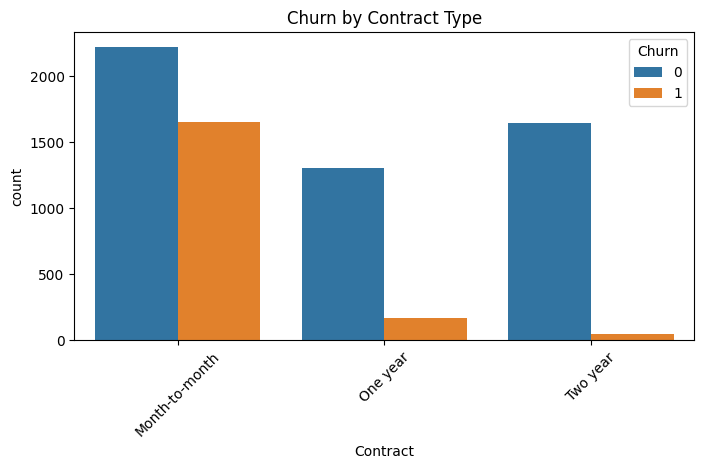

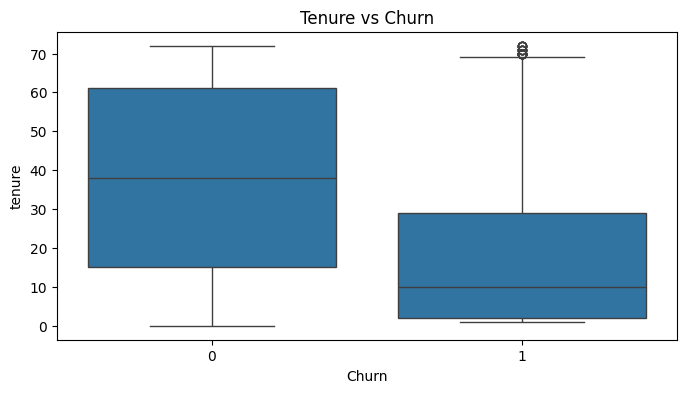

NameError: name 'Pipeline' is not defined

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Load the dataset
try:
    df = pd.read_csv(r"C:\Users\abbas\Downloads\archive (2)\Telco.csv")
except FileNotFoundError:
    df = pd.read_csv('https://raw.githubusercontent.com/IBM/telco-customer-churn-on-ic14/master/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Clean basic columns
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

# Convert target to binary
if 'Churn' in df.columns:
    df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})

print('Shape:', df.shape)
print('Churn rate:', round(df['Churn'].mean(), 4))

# Quick EDA
plt.figure(figsize=(8, 4))
contract_col = 'Contract' if 'Contract' in df.columns else df.select_dtypes(include=['object']).columns[0]
sns.countplot(data=df, x=contract_col, hue='Churn')
plt.xticks(rotation=45)
plt.title('Churn by Contract Type')
plt.show()

plt.figure(figsize=(8, 4))
if 'tenure' in df.columns:
    sns.boxplot(data=df, x='Churn', y='tenure')
    plt.title('Tenure vs Churn')
    plt.show()

# Prepare data
X = df.drop(columns=['Churn'])
y = df['Churn']

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Decision Tree model
clf_tree = Pipeline([
    ('preprocess', preprocess),
    ('model', DecisionTreeClassifier(random_state=42, max_depth=5))
])
clf_tree.fit(X_train, y_train)
pred_tree = clf_tree.predict(X_test)

# Logistic Regression model
clf_lr = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])
clf_lr.fit(X_train, y_train)
pred_lr = clf_lr.predict(X_test)

# Evaluate both models
for name, pred in [('Decision Tree', pred_tree), ('Logistic Regression', pred_lr)]:
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, zero_division=0)
    rec = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)
    print(f'\n{name}')
    print('Accuracy:', round(acc, 4))
    print('Precision:', round(prec, 4))
    print('Recall:', round(rec, 4))
    print('F1:', round(f1, 4))
    print(classification_report(y_test, pred, zero_division=0))

# Feature importances from tree model
feature_names = clf_tree.named_steps['preprocess'].get_feature_names_out()
importances = clf_tree.named_steps['model'].feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(10)
print('\nTop 10 features driving churn:')
print(feature_importance_df)

print('\nTop 3 features driving churn:')
print(feature_importance_df.head(3))

# Business summary
summary = (
    "Customers with shorter relationships, month-to-month contracts, and higher monthly charges "
    "appear more likely to leave. The model suggests that churn risk is concentrated among "
    "newer customers and those on less stable plans. A practical response would be to target "
    "retention offers and proactive support toward these groups before they cancel."
)
print('\nBusiness Summary:')
print(summary)
